1. подаем изображение

2. очищаем, выпрямляем и находим нотные линии 

In [23]:
from pathlib import Path

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import cv2

In [25]:
HOUGH_THRESHOLD   = 100   # порог Хафа для оценки угла
MIN_LINE_LENGTH   = 150   # мин. длина линии для Хафа (пикс.)
MAX_LINE_GAP      = 15    # макс. разрыв в линии для Хафа
PEAK_MIN_DISTANCE = 5     # мин. расстояние между пиками профиля (пикс.)
PEAK_PROMINENCE   = 0.2  # мин. заметность пика (доля от макс.)
TOLERANCE_PX      = 5     # допуск совпадения детекции с GT (пикс.)

PATCH_SIZE = 640
STRIDE = 400
MIN_BLACK_PIXELS = 500   # минимум чёрных пикселей в бинарном куске

plt.rcParams['figure.dpi'] = 150

TARGET_STEP = 10.5 # среднее расстояние между линиями стана в датасете

In [ ]:

def deskew(image: np.ndarray) -> np.ndarray:
    lines = cv2.HoughLinesP(
        image,
        rho=1, theta=np.pi / 180,
        threshold=HOUGH_THRESHOLD,
        minLineLength=MIN_LINE_LENGTH,
        maxLineGap=MAX_LINE_GAP
    )

    if lines is None:
        print("Хаф не нашёл линий — угол принят 0")
        return image

    angles = []
    for x1, y1, x2, y2 in lines[:, 0]:
        a = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        if abs(a) < 10:
            angles.append(a)

    if not angles:
        print("Нет горизонтальных линий — угол принят 0")
        return image

    angle = float(np.median(angles))
    h, w = image.shape[:2]
    
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)
    M[0, 2] += new_w / 2 - w / 2
    M[1, 2] += new_h / 2 - h / 2
    
    return cv2.warpAffine(image, M, (new_w, new_h), 
                          flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_CONSTANT,
                          borderValue=0)


def compute_scale(peaks: np.ndarray) -> float:
    if len(peaks) < 5:
        return 1.0
    diffs = np.diff(np.sort(peaks))                
    median_step = np.median(diffs)
    return TARGET_STEP / median_step if median_step else 1.0

def get_peaks(img_bgr):
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    binary_img = cv2.adaptiveThreshold(
            img_gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            blockSize=15, C=10
        )

    binary_aligned    = deskew(binary_img)
    profile           = binary_aligned.sum(axis=1) / binary_aligned.shape[1]
    detected_peaks, _ = find_peaks(
        profile,
        height=profile.max()*0.4,
        distance=PEAK_MIN_DISTANCE,
        prominence=PEAK_PROMINENCE * profile.max()
    )
    return detected_peaks, binary_aligned

def detect_staff_lines(image_path: Path):
    try:
        img_bgr = cv2.imread(str(image_path))

        if img_bgr is None:
            raise ValueError(f"Не удалось прочитать изображение (возможно, файл поврежден): {image_path}")
        detected_peaks, binary_aligned = get_peaks(img_bgr)
        scale = compute_scale(detected_peaks)
        if abs(scale - 1.0) > 0.05:           
            new_w = int(img_bgr.shape[1] * scale)
            new_h = int(img_bgr.shape[0] * scale)
            img_bgr = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
            detected_peaks, binary_aligned = get_peaks(img_bgr)
        
        return detected_peaks, cv2.bitwise_not(binary_aligned)#ИНВЕРТИРУЕМ ОБРАТНО
    except Exception as e:
        print(f"[ОШИБКА] {image_path.name}: {e}")
        return None

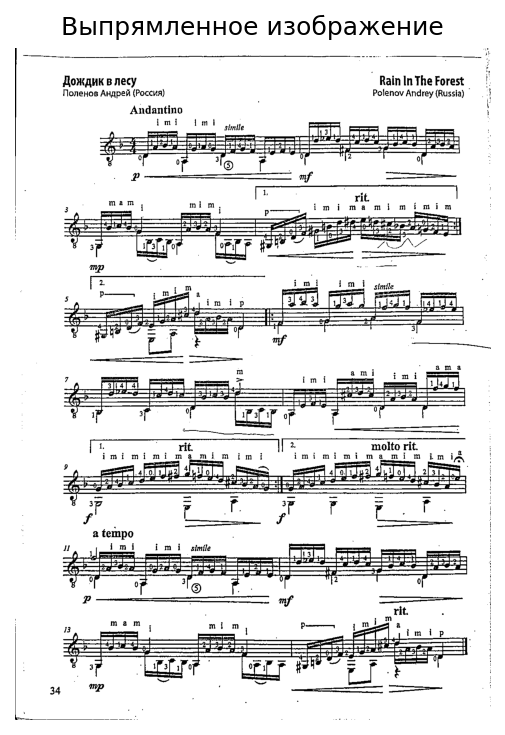

In [27]:
img_path = Path('./demo_images/notes1.jpg')

lines, img = detect_staff_lines(img_path)

plt.figure(figsize=(14, 5))
plt.imshow(img, cmap='gray')
plt.title("Выпрямленное изображение")
plt.axis('off')
plt.tight_layout()
plt.show()

3. нарезаем изображение на куски 640х640 со сдвигом 400. Сохраняем информацию о сдвиге каждого куска чтобы потом восстановить


In [ ]:
def slice_image(img: np.ndarray):
    h, w = img.shape[:2]
    patches = []
    for y in range(0, h, STRIDE):           
        for x in range(0, w, STRIDE):
            patch = np.full((PATCH_SIZE, PATCH_SIZE), 255, dtype=np.uint8)
            src_h = min(PATCH_SIZE, h - y)
            src_w = min(PATCH_SIZE, w - x)
            patch[:src_h, :src_w] = img[y:y + src_h, x:x + src_w]
            if np.sum(patch < 128) >= MIN_BLACK_PIXELS:  
                patches.append((patch, x, y))
    return patches

In [29]:
patches = slice_image(img)
patches

[(array([[255,   0, 255, ..., 255, 255, 255],
         [  0,   0,   0, ..., 255, 255, 255],
         [  0,   0,   0, ..., 255, 255, 255],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]], shape=(640, 640), dtype=uint8),
  0,
  0),
 (array([[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]], shape=(640, 640), dtype=uint8),
  400,
  0),
 (array([[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         ...,
         [  0,   0,   0, ..., 255, 255, 255],
         [  0,   0,   0, ..., 255, 255, 255],
         [  0,   0,   0, ..., 255, 255, 255]], shape=(640, 640), dtype=uint8),
  800,


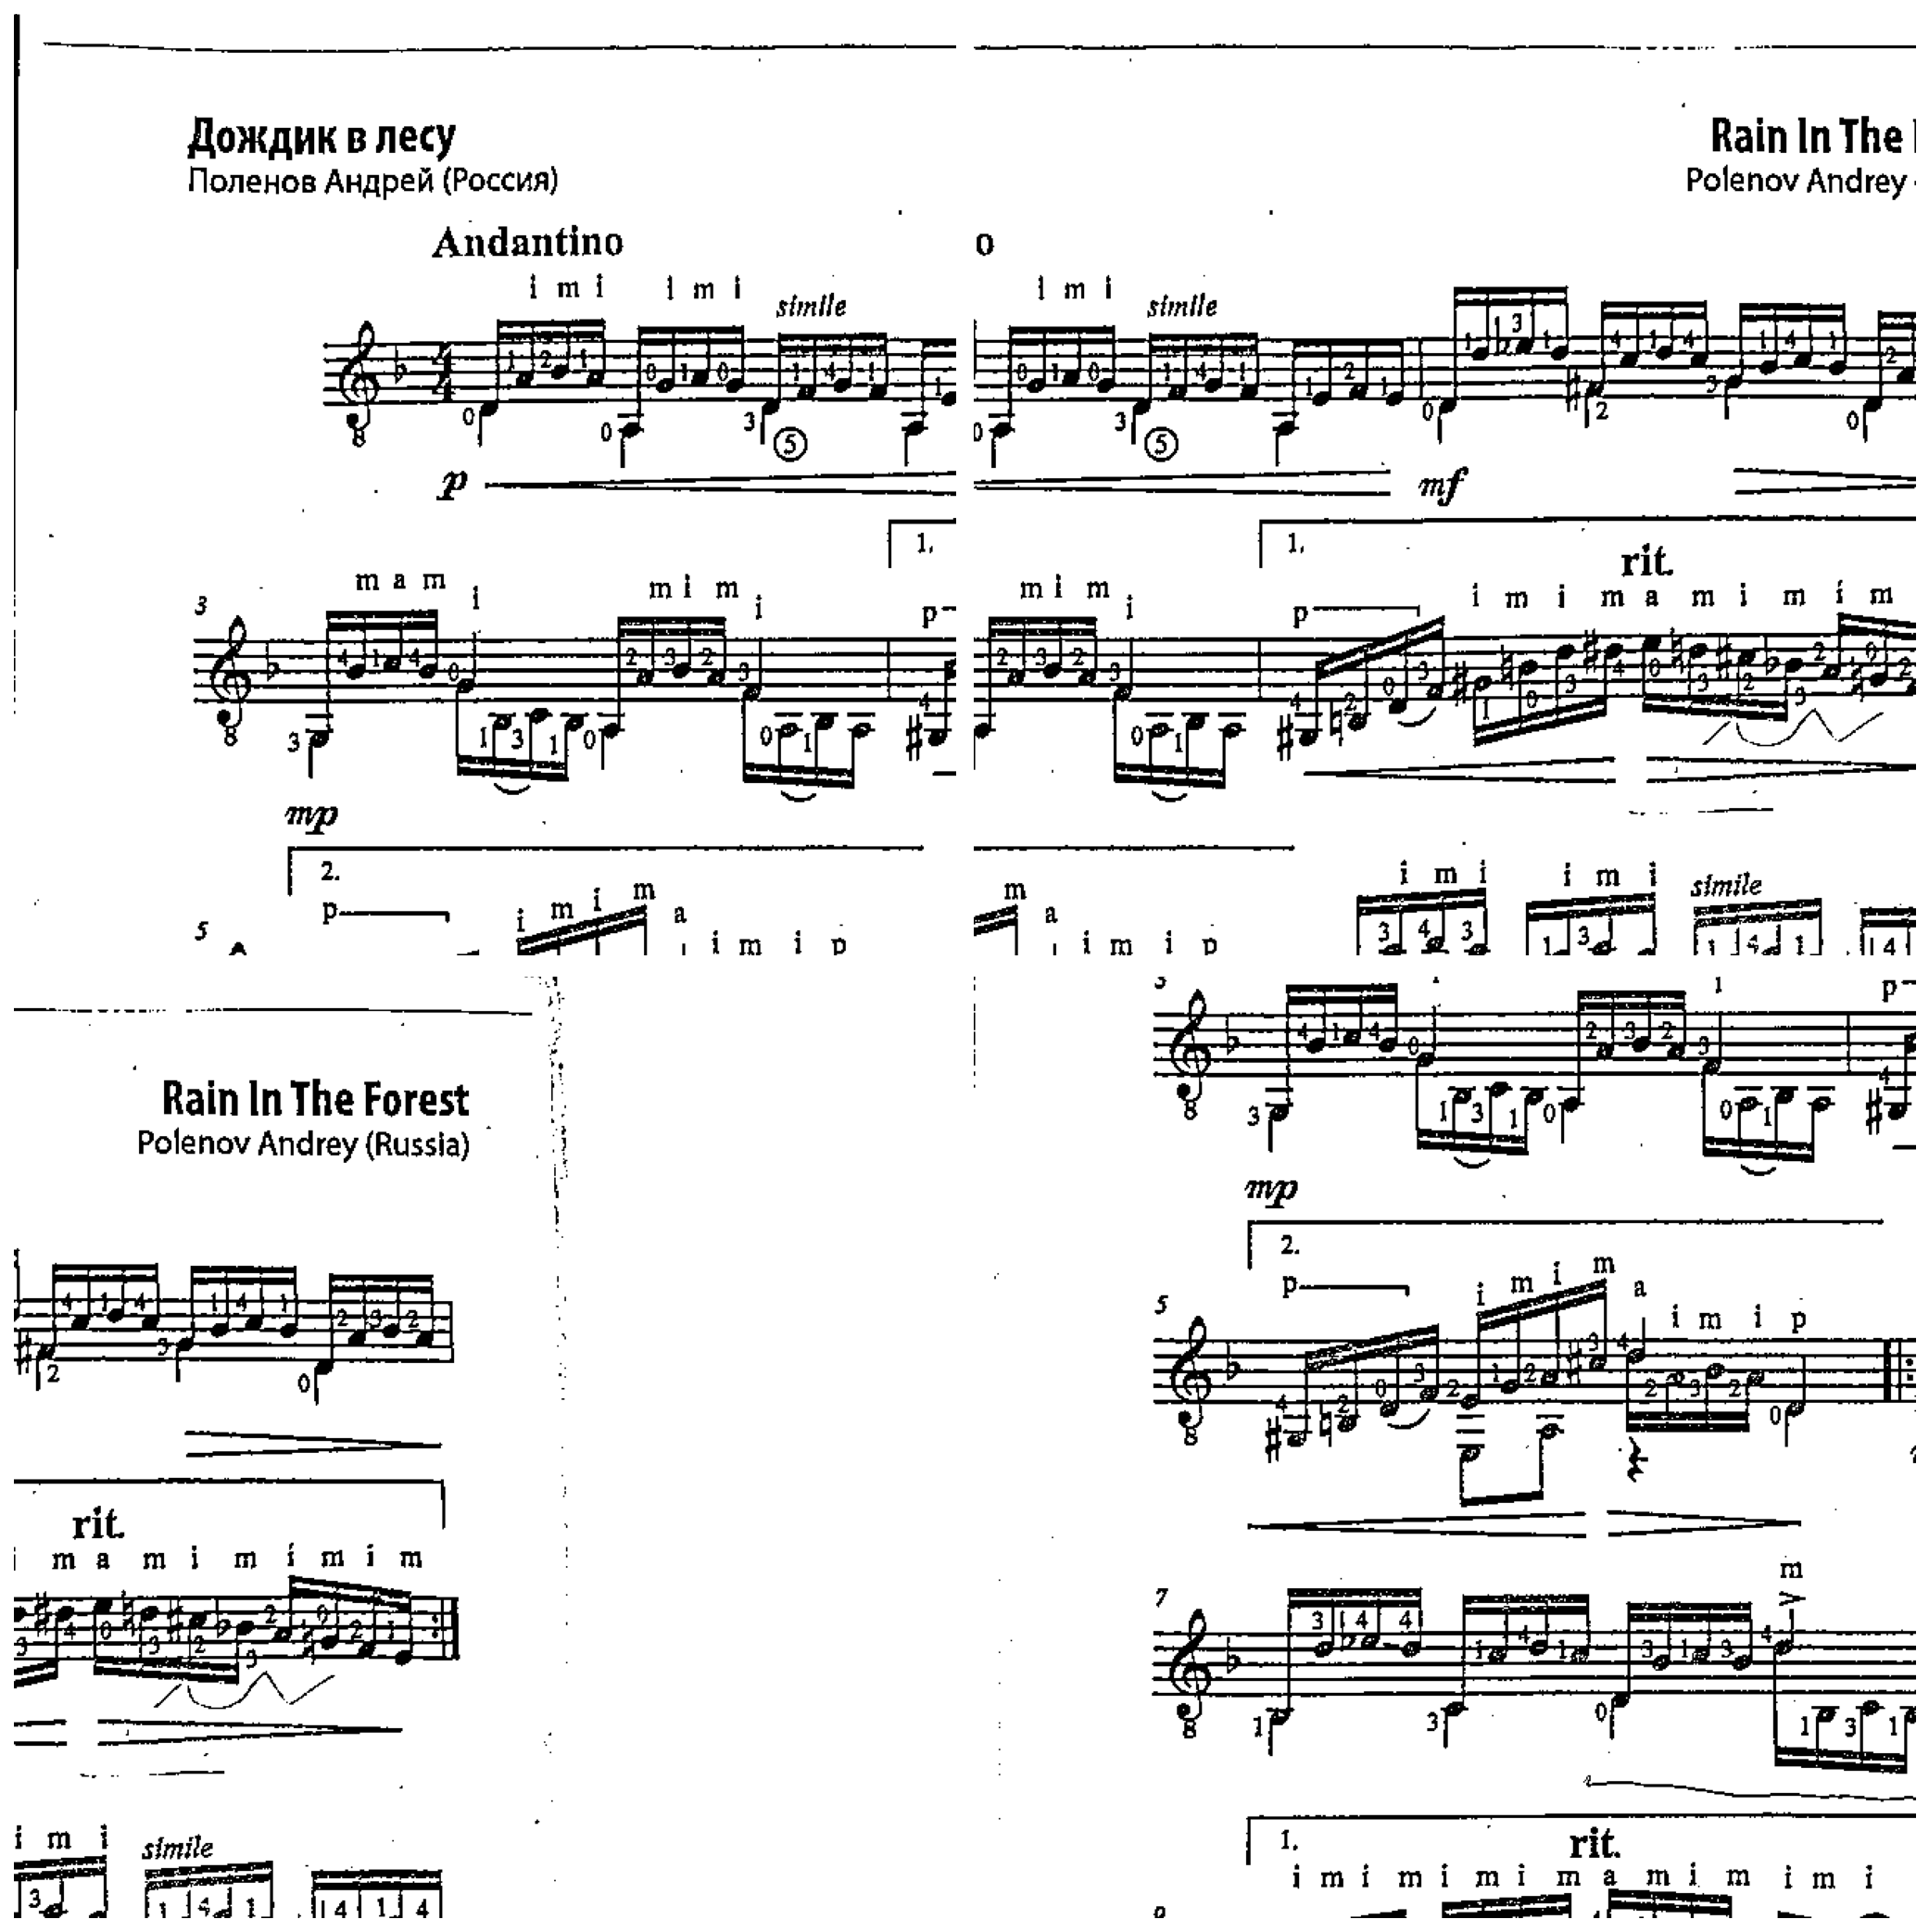

In [30]:

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes[0, 0].imshow(patches[0][0], cmap='gray')
axes[0, 0].axis('off')
axes[0, 1].imshow(patches[1][0], cmap='gray')
axes[0, 1].axis('off')
axes[1, 0].imshow(patches[2][0], cmap='gray')
axes[1, 0].axis('off')
axes[1, 1].imshow(patches[3][0], cmap='gray')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

4. пропускаем через нейросеть для получения положений нот

In [31]:
from ultralytics import YOLO

model_path = 'runs/detect/final/weights/best.pt'
model = YOLO(model_path)




5. объединяем информацию с нотами обратно с лист. Избавляемся от дубликатов на пересечении кусков (берем то где больше уверенность)

In [32]:
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict, Set
from collections import defaultdict

@dataclass
class Detection:
    x1: float
    y1: float
    x2: float
    y2: float
    conf: float
    cls: int
    # Поля, заполняемые позднее:
    pitch_name:  str   = ""
    staff_pos:   int   = 0
    applied_acc: int   = None   # cls знака, повлиявшего на ноту (или None)
    is_valid:    bool  = True
 
    @property
    def cx(self) -> float:
        return (self.x1 + self.x2) / 2
 
    @property
    def cy(self) -> float:
        return (self.y1 + self.y2) / 2
 
 
@dataclass
class Staff:
    lines: List[float]          # y-координаты 5 линий, отсортированные 
    obj: List[Detection] = field(default_factory=list)
    notes: List[Detection] = field(default_factory=list)
    accs: List[Detection] = field(default_factory=list)
 
    @property
    def center_y(self) -> float:
        return float(np.mean(self.lines))
 
    @property
    def step(self) -> float:#Средний шаг между соседними линиями (пол-шага = один интервал).
        diffs = np.diff(self.lines)
        return float(np.mean(diffs))

In [33]:
OTHER_CLASSES = {8,9,10,11,12,13,14,15}

In [34]:
PITCH_MAP = { #скрипичный ключ
    # добавочные линии снизу
    -7: "E3",
    -6: "F3",
    -5: "G3",
    -4: "A3",
    -3: "B3",
    -2: "C4",
    -1: "D4",
    # стан
    0: "E4",
    1: "F4",
    2: "G4",
    3: "A4",
    4: "B4",
    5: "C5",
    6: "D5",
    7: "E5",
    8: "F5",
    # добавочные линии сверху
    9: "G5",
    10: "A5",
    11: "B5",
    12: "C6",
    13: "D6",
    14: "E6",
    15: "F6",
    16: "G6",
    17: "A6",
    18: "B6",
}

NOTE_CLASSES       = {0, 1}
ACCIDENTAL_CLASSES = {2, 3, 4, 5, 6}
CLEF_CLASS         = 7


LOCAL_ACC_PROXIMITY = 6 # Максимальное расстояние поиска локального знака (в шагах стана)

In [35]:
def collect_detections(patches, model) -> List[Detection]:
    all_dets: List[Detection] = []
    for patch_img, ox, oy in patches:
        patch_img = cv2.cvtColor(patch_img, cv2.COLOR_GRAY2BGR)
        results = model(patch_img, verbose=False, end2end=False)
        for result in results:
            for box in result.boxes:
                if int(box.cls[0]) in OTHER_CLASSES: 
                   continue
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                all_dets.append(Detection(
                    x1=x1 + ox, y1=y1 + oy,
                    x2=x2 + ox, y2=y2 + oy,
                    conf=float(box.conf[0]),
                    cls=int(box.cls[0]),
                ))
    return all_dets

def iou(a: Detection, b: Detection) -> float:
    ix1 = max(a.x1, b.x1); iy1 = max(a.y1, b.y1)
    ix2 = min(a.x2, b.x2); iy2 = min(a.y2, b.y2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    area_a = (a.x2 - a.x1) * (a.y2 - a.y1)
    area_b = (b.x2 - b.x1) * (b.y2 - b.y1)
    return inter / (area_a + area_b - inter)
 
 
def nms(detections: List[Detection], iou_threshold: float = 0.4) -> List[Detection]:
    if not detections:
        return []
 
    by_class: dict = defaultdict(list)
    for d in detections:
        key = 'note' if d.cls in NOTE_CLASSES else d.cls
        by_class[key].append(d)
 
    kept: List[Detection] = []
    for cls_dets in by_class.values():
        cls_dets = sorted(cls_dets, key=lambda d: d.conf, reverse=True)
        suppressed = [False] * len(cls_dets)
        for i, det in enumerate(cls_dets):
            if suppressed[i]:
                continue
            kept.append(det)
            for j in range(i + 1, len(cls_dets)):
                if not suppressed[j] and iou(det, cls_dets[j]) > iou_threshold:
                    suppressed[j] = True
    return kept

6. сортируем ноты по положению: распределяем по станам и потом по x-координате слева направо.  Для нескольких станов считаем что нота относится к тому, к центру которого она ближе. 

In [36]:
def group_lines_into_staffs(peaks: np.ndarray, gap_factor: float = 2.0) -> List[Staff]:
    lines_per_staff = 5
    if len(peaks) < lines_per_staff:
        return []
 
    ys = np.sort(peaks).astype(float)
    diffs = np.diff(ys)
    median_step = float(np.median(diffs))
 
    staffs: List[Staff] = []
    current: List[float] = [ys[0]]
 
    for i, d in enumerate(diffs):
        if d > gap_factor * median_step:
            # разрыв -> заканчиваем текущий стан
            if len(current) == lines_per_staff:
                staffs.append(Staff(lines=current))
            current = [ys[i + 1]]
        else:
            current.append(ys[i + 1])
 
    if len(current) == lines_per_staff:
        staffs.append(Staff(lines=current))
 
    return staffs

def assign_obj_to_staffs( detections: List[Detection], staffs: List[Staff]):    
    for det in detections:
        best_staff = min(staffs, key=lambda s: abs(det.cy - s.center_y)) #Каждую ноту добавляем в стан, к центру которого она ближе всего по y.
        best_staff.obj.append(det)
 
    for staff in staffs:
        staff.obj.sort(key=lambda d: d.cx)#сортируем слева направо

#### Ступени стана от нижней (1-я линия) вверх.
Позиция 0  = первая (нижняя) линия стана

Позиция 1  = первый просвет (между 1 и 2 линией)

Позиция 2  = вторая линия … и т.д.

Отрицательные — ноты ниже стана, > 8 — ноты выше стана

7. определяем что за ноты по положению центра ноты относительно нотных линий (для тех которые выше или ниже смотрим на расстояение между станами и прибавляем воображаемые линии).

In [37]:
def get_obj_y(det: Detection) -> float:
    if det.cls == 3:
        return det.y1 + (det.y2 - det.y1) * 0.75
    return det.cy

def symb_position(det: Detection, staff: Staff) -> float:
    half_step = staff.step / 2          # один интервал
    bottom_line_y = staff.lines[-1]      
    symb_y = get_obj_y(det)
    raw_pos = (bottom_line_y - symb_y) / half_step
    return round(raw_pos) 


In [38]:
ACCIDENTAL_SYMBOL = {2: '#', 3: 'b', 4: 'nat', 5: '##', 6: 'bb'}

CLASS_NAME = {
    0: 'filled',
    1: 'open',
    2: 'sharp#',
    3: 'flatb',
    4: 'natural',
    5: 'dbl_sharp##',
    6: 'dbl_flatbb',
    7: 'clef',
    8: 'dot',
    9: 'stem',
    10: 'beam',
    11: 'rest1',
    12: 'rest2',
    13: 'other_clef',
    14: 'curve',
    15: 'other',
}


In [ ]:
def nearest_staff(det: Detection, staffs: List[Staff]) -> Staff:
    return min(staffs, key=lambda s: abs(det.cy - s.center_y))


def detect_key_signatures(
    staffs: List[Staff],
    all_dets: List[Detection],
) -> dict:
    """
    Для каждого стана определяет ключевые знаки альтерации —
    знаки, стоящие между скрипичным ключом и первой нотой.
    Бекар (cls=4) в ключевых знаках не допускается.
    """
    clefs   = [d for d in all_dets if d.cls == CLEF_CLASS]
    ks_pool = [d for d in all_dets if d.cls in ACCIDENTAL_CLASSES - {4}]

    result: dict = {}

    for staff in staffs:
        s_clefs = sorted(
            [c for c in clefs if abs(c.cy - staff.center_y) < staff.step * 5],
            key=lambda c: c.cx,
        )
        if not s_clefs:
            clef_x2 = 0
        else:
            clef_x2 = s_clefs[0].x2
        
        first_note_x = min((n.cx for n in staff.obj if n.cls in NOTE_CLASSES), default=float('inf'))

        # Знаки между правым краем ключа и первой нотой
        zone_accs = [
            a for a in ks_pool
            if clef_x2 < a.cx < first_note_x
            and abs(get_obj_y(a) - staff.center_y) < staff.step * 5
        ]

        ks: dict = {}
        for a in sorted(zone_accs, key=lambda a: a.cx):
            pos       = symb_position(a, staff)
            ks[pos]   = a.cls   
        result[id(staff)] = ks

    return result


def find_local_acc(
    note: Detection,
    staff: Staff,
    note_pos: int,
) -> Detection | None:
    max_dx     = staff.step * LOCAL_ACC_PROXIMITY
    candidates = [
        a for a in staff.accs
        if 0 < (note.cx - a.cx) < max_dx
        and symb_position(a, staff) == note_pos
    ]
    return max(candidates, key=lambda a: a.cx) if candidates else None


def compute_pitch_with_acc(
    note: Detection,
    staff: Staff,
    key_sig: dict,
) -> tuple:
    pos   = symb_position(note, staff)
    local = find_local_acc(note, staff, pos)

    if local is not None:
        applied = local.cls
    elif pos in key_sig:
        applied = key_sig[pos]
    else:
        applied = None

    base_name = PITCH_MAP.get(pos, f"pos={pos}")
    if applied is not None:
        symbol = ACCIDENTAL_SYMBOL.get(applied, '')
        pitch = base_name + symbol   
    else:
        pitch = base_name

    is_valid = pos in PITCH_MAP

    return pitch, pos, applied, is_valid

In [ ]:
dets = collect_detections(patches, model)
dets = nms(dets)

staffs = group_lines_into_staffs(lines)
if not staffs:
    raise ValueError("Не удалось сгруппировать линии в станы. Проверьте detected_peaks.")

assign_obj_to_staffs(dets, staffs)

# notes_raw  = [d for d in dets if d.cls in NOTE_CLASSES]
accs_all   = [d for d in dets if d.cls in ACCIDENTAL_CLASSES]
# clefs_all  = [d for d in dets if d.cls == CLEF_CLASS]

acc_by_staff: dict = {id(s): [] for s in staffs}
for a in accs_all:
    s = nearest_staff(a, staffs)
    acc_by_staff[id(s)].append(a)

key_sigs = detect_key_signatures(staffs, dets)

invalid_obj: List[Detection] = []

for staff in staffs:
    ks     = key_sigs[id(staff)]
    staff.accs = acc_by_staff[id(staff)]

    valid  = []
    notes = []
    for obj in staff.obj:
        pitch, pos, applied, is_valid = compute_pitch_with_acc(
            obj, staff, ks
        )
        obj.pitch_name  = pitch
        obj.staff_pos   = pos
        obj.applied_acc = applied
        obj.is_valid    = is_valid
        (valid if is_valid else invalid_obj).append(obj)
        if obj.cls in NOTE_CLASSES and is_valid:
            notes.append(obj)
    staff.obj = valid
    staff.notes = notes


valid_accs:   List[Detection] = []
invalid_accs: List[Detection] = []

for staff in staffs:
    for acc in acc_by_staff[id(staff)]:
        pos            = symb_position(acc, staff)
        acc.staff_pos  = pos
        acc.pitch_name = PITCH_MAP.get(pos, f"pos={pos}")
        acc.is_valid   = pos in PITCH_MAP
        (valid_accs if acc.is_valid else invalid_accs).append(acc)



In [41]:
def print_notes(
    staffs:      List[Staff],
    key_sigs:    dict = None,
    invalid:   List[Detection] = None,
    valid_accs:  List[Detection] = None,
):
    if not staffs:
        print("Станы не найдены.")
        return

    for i, staff in enumerate(staffs, 1):
        ks = (key_sigs or {}).get(id(staff), {})

        print(f"\n{'═'*70}")
        print(f"  Стан {i}  |  центр y = {staff.center_y:.1f}  |  шаг = {staff.step:.1f} пикс.")
        print(f"{'═'*70}")

        if ks:
            parts = [
                f"pos {p}: {CLASS_NAME[c]} ({PITCH_MAP.get(p, '?')})"
                for p, c in sorted(ks.items())
            ]
            print(f"  Ключевые знаки: {', '.join(parts)}")
        else:
            print("  Ключевые знаки: нет")

        if valid_accs:
            s_accs = [
                a for a in valid_accs
                if abs(get_obj_y(a) - staff.center_y) < staff.step * 5
            ]
            if s_accs:
                print(f"\n  Знаки альтерации ({len(s_accs)} шт.):")
                print(f"  {'Класс':<16}{'pos':<6}{'Нота':<8}{'Увер.':<8}{'X':>7}  {'Y'}")
                print(f"  {'─'*50}")
                for a in sorted(s_accs, key=lambda a: a.cx):
                    cls_str = CLASS_NAME.get(a.cls, str(a.cls))
                    is_ks   = a.staff_pos in ks
                    flag    = " [ключ]" if is_ks else ""
                    print(
                        f"  {cls_str:<16}{a.staff_pos:<6}{a.pitch_name:<8}"
                        f"{a.conf:<8.3f}{a.cx:>7.1f}  {a.cy:.1f}{flag}"
                    )

        if not staff.obj:
            print("\n  Ноты: не обнаружены")
            continue

        print(f"\n  {'№':<4}{'Нота':<8}{'Alt':<6}{'Класс':<14}{'pos':<6}{'Увер.':<8}{'X':>7}  {'Y'}")
        print(f"  {'─'*62}")
        for j, note in enumerate(staff.obj, 1):
            acc_sym = ACCIDENTAL_SYMBOL.get(note.applied_acc, '-') if note.applied_acc is not None else '-'
            cls_str = CLASS_NAME.get(note.cls, str(note.cls))
            print(
                f"  {j:<4}{note.pitch_name:<8}{acc_sym:<6}{cls_str:<14}"
                f"{note.staff_pos:<6}{note.conf:<8.3f}{note.cx:>7.1f}  {note.cy:.1f}"
            )

    # Ошибочные детекции
    if invalid:
        print(f"\n{'═'*70}")
        print(f"  Ошибочные детекции: {len(invalid)} шт.")
        print(f"{'═'*70}")
        print(f"  {'Класс':<16}{'pos':<8}{'Увер.':<8}{'X':>7}  {'Y'}")
        print(f"  {'─'*44}")
        for det in invalid:
            cls_str = CLASS_NAME.get(det.cls, str(det.cls))
            pos     = getattr(det, 'staff_pos', '?')
            print(
                f"  {cls_str:<16}{str(pos):<8}{det.conf:<8.3f}"
                f"{det.cx:>7.1f}  {det.cy:.1f}"
            )
print_notes(staffs, key_sigs, invalid_obj, valid_accs)



══════════════════════════════════════════════════════════════════════
  Стан 1  |  центр y = 241.0  |  шаг = 10.0 пикс.
══════════════════════════════════════════════════════════════════════
  Ключевые знаки: pos 3: flatb (A4)

  Знаки альтерации (4 шт.):
  Класс           pos   Нота    Увер.         X  Y
  ──────────────────────────────────────────────────
  flatb           3     A4      0.499     262.3  238.4 [ключ]
  flatb           -5    G3      0.389     403.5  280.8
  natural         2     G4      0.554     808.0  249.3
  natural         6     D5      0.643    1045.1  231.1

  №   Нота    Alt   Класс         pos   Увер.         X  Y
  ──────────────────────────────────────────────────────────────
  1   A4b     b     clef          3     0.908     234.7  247.3
  2   A4      b     flatb         3     0.499     262.3  238.4
  3   C4      -     filled        -2    0.872     322.8  269.3
  4   A4b     b     filled        3     0.858     370.6  243.9
  5   G3      -     flatb         

In [ ]:
def _draw_label(
    vis:       np.ndarray,
    text:      str,
    anchor_x:  int,
    anchor_y:  int,
    color:     tuple,
    label_reg: list,
    staff_ys:  list,
    prefer_above: bool = True,
):
    FONT = cv2.FONT_HERSHEY_SIMPLEX
    SCALE = 0.4
    THICKNESS = 1
    PAD  = 2
    (tw, th), bl = cv2.getTextSize(text, FONT, SCALE, THICKNESS)
    lh = th + bl + PAD * 2   # полная высота блока
    H, W = vis.shape[:2]

    tx = max(0, min(anchor_x, W - tw - PAD * 2 - 1))

    if prefer_above:
        y_top = anchor_y - lh - 3
        step  = -(lh + 3)
    else:
        y_top = anchor_y + 3
        step  = lh + 3

    for _ in range(25):
        if y_top < 0:
            y_top = anchor_y + 3
            step  = abs(step)
        if y_top + lh > H:
            y_top = H - lh - 1
            break

        box = (tx, y_top, tx + tw + PAD * 2, y_top + lh)

        # Проверка наложения на линии стана
        staff_clear = not any(
            box[1] - 1 <= int(sy) <= box[3] + 1 for sy in staff_ys
        )
        # Проверка наложения на уже размещённые подписи
        label_clear = all(
            box[2] <= r[0] or box[0] >= r[2] or
            box[3] <= r[1] or box[1] >= r[3]
            for r in label_reg
        )

        if staff_clear and label_clear:
            break

        y_top += step

    y_top = max(0, min(y_top, H - lh - 1))
    box   = (tx, y_top, tx + tw + PAD * 2, y_top + lh)
    label_reg.append(box)

    cv2.rectangle(vis, (box[0], box[1]), (box[2], box[3]), (255, 255, 255), -1)
    cv2.rectangle(vis, (box[0], box[1]), (box[2], box[3]), color, 1)
    cv2.putText(
        vis, text, (tx + PAD, y_top + PAD + th),
        FONT, SCALE, color, THICKNESS, cv2.LINE_AA,
    )


def visualize_notes(
    img:              np.ndarray,
    staffs:           List[Staff],
    invalid_accs:     List[Detection] = None,
    invalid_notes:  List[Detection] = None,
    output_path:      str   = None,
):
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if img.ndim == 2 else img.copy()
    H, W = vis.shape[:2]

    # Цвета (BGR)
    STAFF_COLORS = [
        (20, 150, 20),    # зелёный
        (0,  100, 210),   # синий
        (0,  160, 180),   # голубой
        (130, 0,  180),   # фиолетовый
        (0,  180, 120),   # бирюзовый
    ]
    C_ERR       = (0,    0,  200)   # красный

    all_staff_ys = [y for staff in staffs for y in staff.lines]
    label_reg: list = []


    for i, staff in enumerate(staffs):
        sc = STAFF_COLORS[i % len(STAFF_COLORS)]
        for y in staff.lines:
            cv2.line(vis, (0, int(y)), (W - 1, int(y)), sc, 1)
        

    for acc in (invalid_accs or []):
        x1, y1, x2, y2 = int(acc.x1), int(acc.y1), int(acc.x2), int(acc.y2)
        cv2.rectangle(vis, (x1, y1), (x2, y2), C_ERR, 1)
        

    for i, staff in enumerate(staffs):
        nc = STAFF_COLORS[i % len(STAFF_COLORS)]
        for note in staff.obj:
            x1, y1, x2, y2 = int(note.x1), int(note.y1), int(note.x2), int(note.y2)
            cv2.rectangle(vis, (x1, y1), (x2, y2), nc, 2)
            if note.cls not in NOTE_CLASSES:
                continue
            label = f"{note.pitch_name} {note.conf:.2f}"
            prefer_above = note.cy <= staff.center_y
            anchor_x = int(note.cx)
            anchor_y = int(note.cy)

            _draw_label(
                vis, label,
                anchor_x, anchor_y, nc, label_reg, all_staff_ys,
                prefer_above
            )

    for det in (invalid_notes or []):
        x1, y1, x2, y2 = int(det.x1), int(det.y1), int(det.x2), int(det.y2)
        cv2.rectangle(vis, (x1, y1), (x2, y2), C_ERR, 1)
        

    plt.figure(figsize=(16, 10))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Распознавание нот с альтерациями")
    plt.axis('off')
    plt.tight_layout()

    if output_path:
        cv2.imwrite(output_path, vis)
        print(f"Визуализация сохранена: {output_path}")
    plt.show()

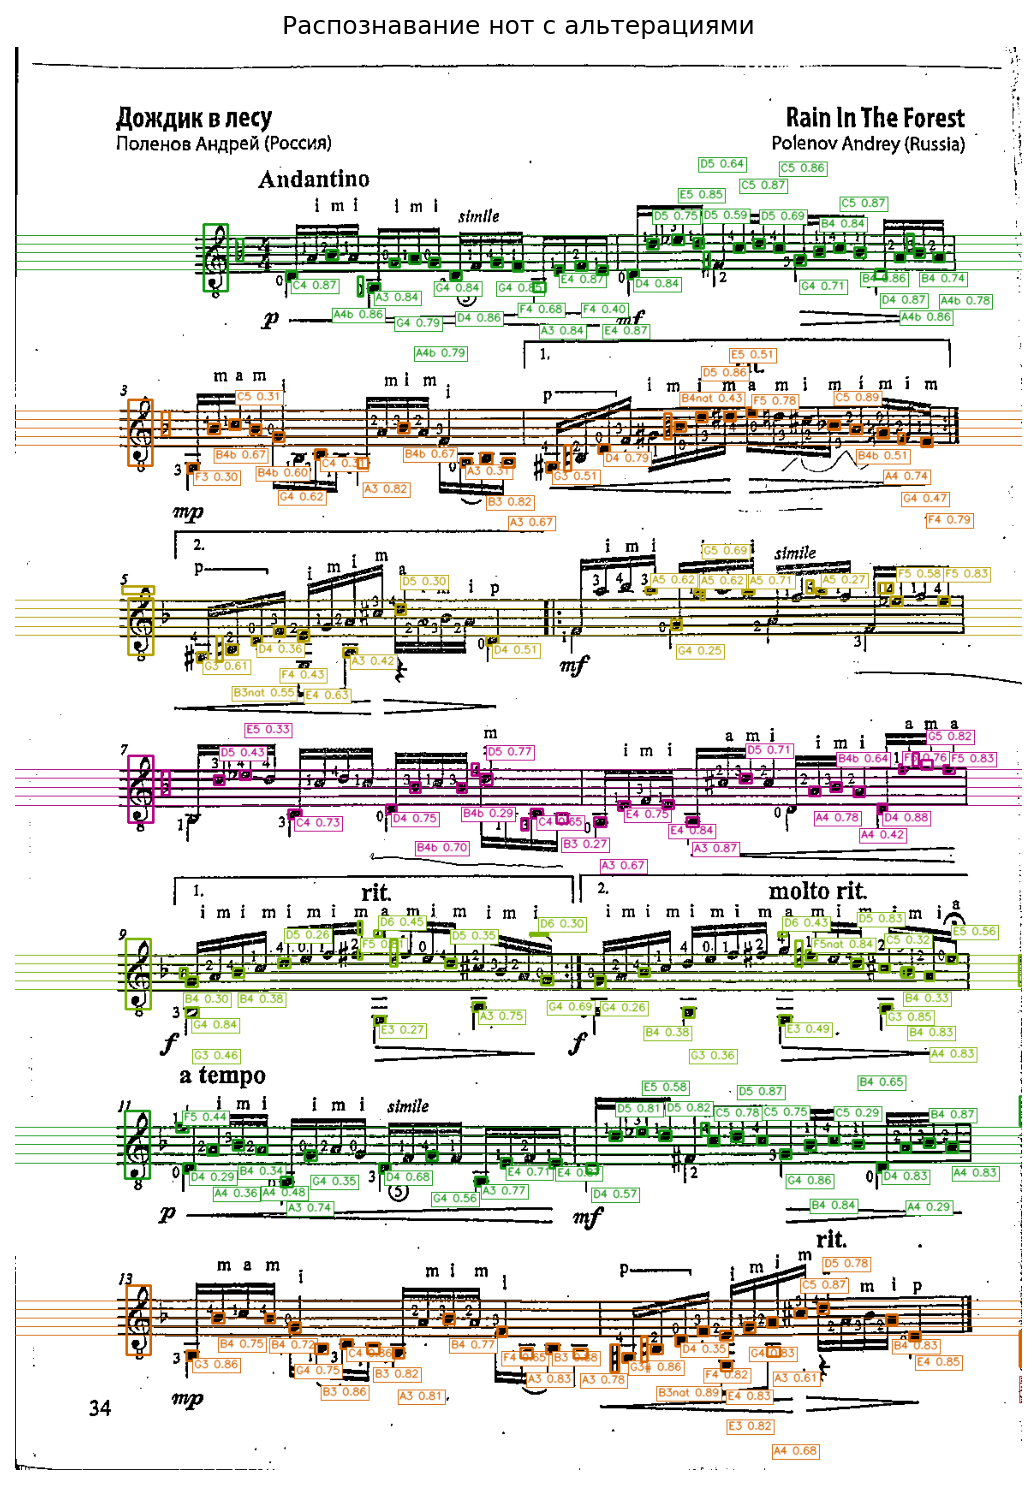

In [43]:
visualize_notes(img, staffs,invalid_accs, invalid_obj)


#### Аппликатура на классической шестиструнной гитаре

Алгоритм Витерби находит оптимальную последовательность (струна, лад)
для каждой ноты, минимизируя суммарное перемещение левой руки по грифу.

Ключевые свойства:
- Квадратичный штраф за прыжки > 3 ладов «заставляет» алгоритм заблаговременно
  перейти на другую струну, а не совершать возвратные прыжки.
- Открытые струны (лад 0) не влияют на позицию руки — нулевой штраф.
- Лёгкое предпочтение первой позиции (нижним ладам) при равных затратах.


════════════════════════════════════════════════════════════════════════
  Стан 1 — аппликатура гитары
════════════════════════════════════════════════════════════════════════
  №   Нота     Тип        Стр.  Лад        MIDI
  ──────────────────────────────────────────────────
  1   C4       нота       5     3          48
  2   A4b      нота       3     1          56
  3   A3       нота       5     откр.      45
  4   G4       нота       3     откр.      55
  5   A4b      нота       3     1          56
  6   G4       нота       3     откр.      55
  7   D4       нота       4     откр.      50
  8   G4       нота       3     откр.      55
  9   F4       нота       4     3          53
  10  A3       нота       5     откр.      45
  11  E4       нота       4     2          52
  12  F4       нота       4     3          53
  13  E4       нота       4     2          52
  14  D4       нота       4     откр.      50
  15  D5       нота       2     3          62
  16  E5       нота       1     

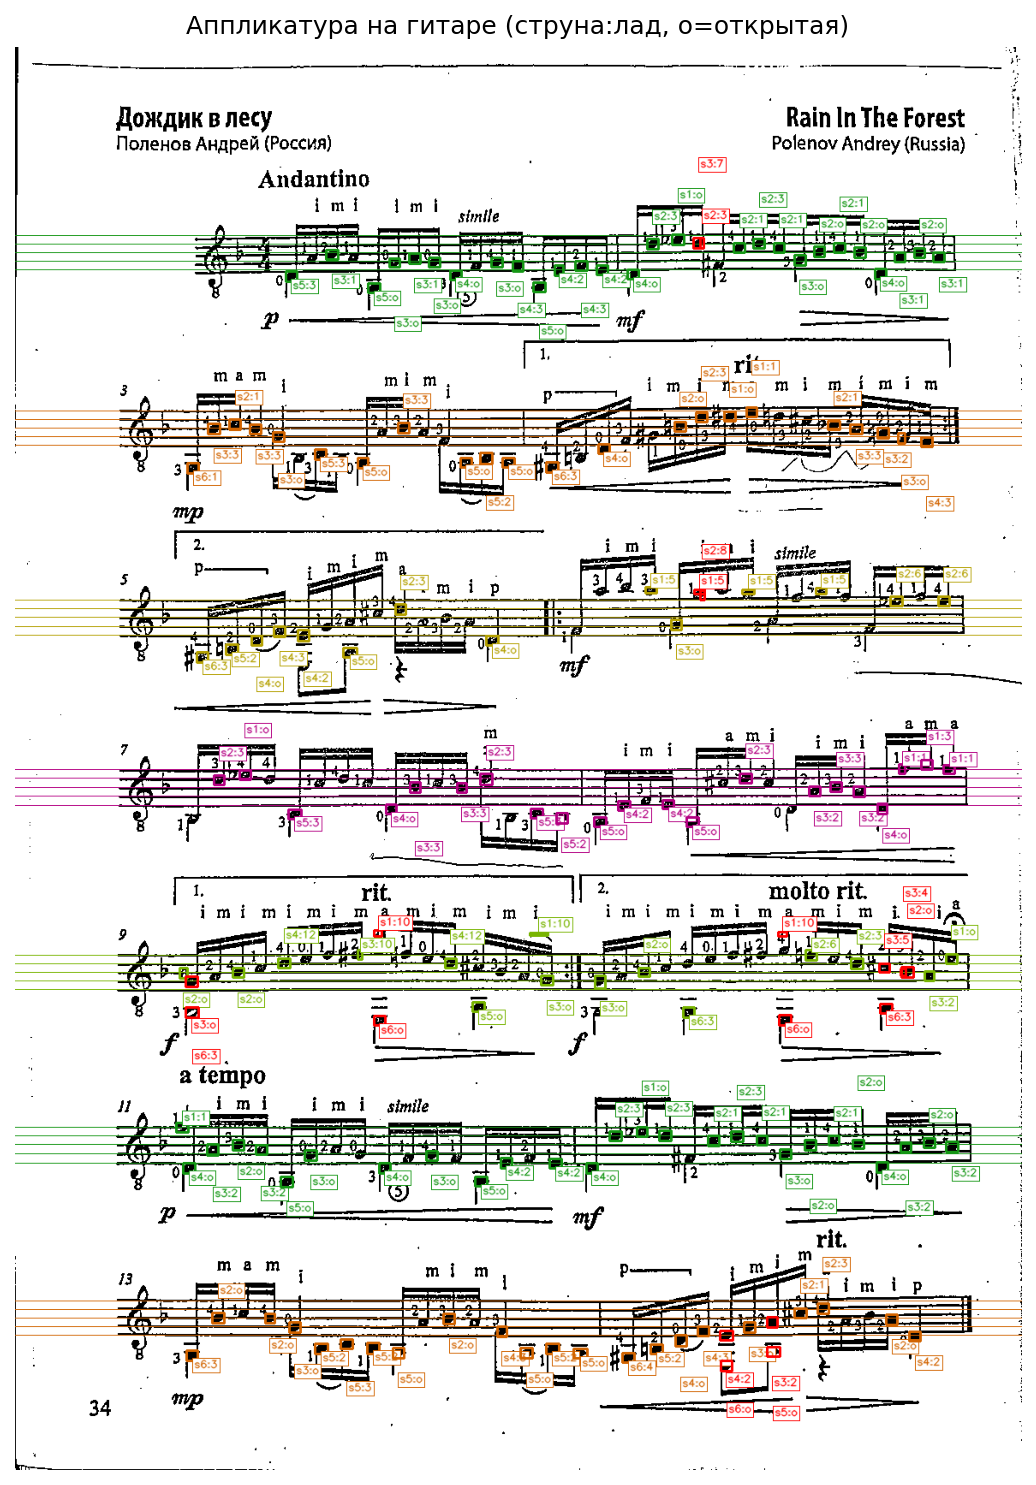

In [ ]:

_NOTE_SEMITONE = {'C': 0, 'D': 2, 'E': 4, 'F': 5, 'G': 7, 'A': 9, 'B': 11}
ACCIDENTAL_DELTA = {'#': 1, 'b': -1, '##': 2, 'bb': -2, 'nat': 0, '': 0} 


def pitch_to_midi(name: str) -> Optional[int]:
    """
    Парсит название ноты ('E4', 'F3', 'A4#') в целое число MIDI.
    C3 = 36 (3 × 12 + 0).
    """
    if not name or name.startswith('pos='):
        return None
    letter = name[0].upper()
    if letter not in _NOTE_SEMITONE:
        return None
    rest = name[1:]
    i = 0
    while i < len(rest) and rest[i].isdigit():
        i += 1
    oct_str = rest[:i]

    acc = rest[i:]

    if not oct_str:
        return None
    try:
        octave = int(oct_str)
    except ValueError:
        return None
    delta = ACCIDENTAL_DELTA.get(acc, 0)
    return octave * 12 + _NOTE_SEMITONE[letter] + delta


# ─── Карта грифа гитары ────────────────────────────────────────────────────────
# Строки 3 и 4 имеют 18 ладов, остальные — 19.
# Струны нумеруются 1–6: 1 = самая тонкая (высокая E5), 6 = самая толстая (низкая E3).

_GUITAR_FRETS: Dict[int, Dict[int, str]] = {
    6: { 0:'E3',  1:'F3',  2:'F3#',  3:'G3',  4:'G3#',  5:'A3',  6:'A3#',
         7:'B3',  8:'C4',  9:'C4#', 10:'D4', 11:'D4#', 12:'E4', 13:'F4',
        14:'F4#', 15:'G4', 16:'G4#', 17:'A4', 18:'A4#', 19:'B4'},
    5: { 0:'A3',  1:'A3#',  2:'B3',  3:'C4',  4:'C4#',  5:'D4',  6:'D4#',
         7:'E4',  8:'F4',  9:'F4#', 10:'G4', 11:'G4#', 12:'A4', 13:'A4#',
        14:'B4', 15:'C5', 16:'C5#', 17:'D5', 18:'D5#', 19:'E5'},
    4: { 0:'D4',  1:'D4#',  2:'E4',  3:'F4',  4:'F4#',  5:'G4',  6:'G4#',
         7:'A4',  8:'A4#',  9:'B4', 10:'C5', 11:'C5#', 12:'D5', 13:'D5#',
        14:'E5', 15:'F5', 16:'F5#', 17:'G5', 18:'G5#'},             
    3: { 0:'G4',  1:'G4#',  2:'A4',  3:'A4#',  4:'B4',  5:'C5',  6:'C5#',
         7:'D5',  8:'D5#',  9:'E5', 10:'F5', 11:'F5#', 12:'G5', 13:'G5#',
        14:'A5', 15:'A5#', 16:'B5', 17:'C6', 18:'C6#'},              
    2: { 0:'B4',  1:'C5',  2:'C5#',  3:'D5',  4:'D5#',  5:'E5',  6:'F5',
         7:'F5#', 8:'G5',  9:'G5#', 10:'A5', 11:'A5#', 12:'B5', 13:'C6',
        14:'C6#', 15:'D6', 16:'D6#', 17:'E6', 18:'F6',  19:'F6#'},
    1: { 0:'E5',  1:'F5',  2:'F5#',  3:'G5',  4:'G5#',  5:'A5',  6:'A5#',
         7:'B5',  8:'C6',  9:'C6#', 10:'D6', 11:'D6#', 12:'E6', 13:'F6',
        14:'F6#', 15:'G6', 16:'G6#', 17:'A6', 18:'A6#', 19:'B6'},
}

_MIDI_TO_POSITIONS: Dict[int, List[Tuple[int, int]]] = {}
for s, fm in _GUITAR_FRETS.items():
    for f, n in fm.items():
        m = pitch_to_midi(n)
        if m is not None:
            _MIDI_TO_POSITIONS.setdefault(m, []).append((s, f))

_GUITAR_MIDI_MIN = min(_MIDI_TO_POSITIONS)
_GUITAR_MIDI_MAX = max(_MIDI_TO_POSITIONS)



@dataclass
class GuitarPlacement:
    note:   Detection
    string: int   # 1–6  (1 = высокая e, 6 = низкая E)
    fret:   int   # 0 = открытая струна;  -1 = вне диапазона гитары
    midi:   int   # -1 = не удалось распарсить
    is_chord:  bool  = False  # True, если нота — часть аккорда
    chord_id:  int   = -1     # индекс аккорда внутри стана (-1 = одиночная нота)

    @property
    def playable(self) -> bool:
        return self.fret >= 0

    def __str__(self) -> str:
        if not self.playable:
            return f"{self.note.pitch_name} → ВНЕ ДИАПАЗОНА"
        fs = "откр." if self.fret == 0 else f"лад {self.fret}"
        return f"{self.note.pitch_name} → струна {self.string}, {fs}"


def move_cost(fret_a: int, fret_b: int) -> float:
    """
    Штраф за перемещение руки с позиции fret_a на fret_b.

    Открытые струны (лад 0) не требуют позиционирования руки -> 0.
    Перемещение в пределах 3 ладов (одна позиция) -> небольшой штраф.
    Прыжок за пределы позиции -> квадратичный штраф, чтобы алгоритм предпочитал
    заблаговременно перейти на другую струну вместо возвратных прыжков.
    """
    if fret_a == 0 or fret_b == 0:
        return 0.0
    dist = abs(fret_b - fret_a)
    if dist == 0:
        return 0.0
    if dist <= 3:                              
        return dist * 0.4
    return 3 * 0.4 + (dist - 3) ** 2 * 0.6   



def group_into_events(
    notes: List[Detection],
    cx_tolerance: float,
) -> List[List[Detection]]:
    """
    Группирует ноты в события (одиночные ноты или аккорды).
    Ноты считаются одновременными если разница cx <= cx_tolerance (пиксели).
    Группа сортируется по высоте ноты (cy) внутри аккорда.
    """
    if not notes:
        return []
    sorted_notes = sorted(notes, key=lambda n: n.cx)
    events: List[List[Detection]] = []
    group = [sorted_notes[0]]
    for note in sorted_notes[1:]:
        if note.cx - group[0].cx <= cx_tolerance:
            group.append(note)
        else:
            events.append(sorted(group, key=lambda n: n.cy))
            group = [note]
    events.append(sorted(group, key=lambda n: n.cy))
    return events


def _hand_fret(assignment: List[Tuple[int, int]]) -> int:
    """
    «Позиция руки» = минимальный прижатый лад в аппликатуре.
    Возвращает 0 если все струны открытые.
    """
    pressed = [f for _, f in assignment if f > 0]
    return min(pressed) if pressed else 0


def chord_candidates(
    event: List[Detection],
    max_span: int,
) -> List[List[Tuple[int, int]]]:
    """
    Перечисляет допустимые аппликатуры для события (нота или аккорд).
    Каждая аппликатура — список (струна, лад), по одному на каждую ноту
    в порядке event.

    Ограничения аккорда:
      - В аккорде каждая струна используется не более одного раза
      - Максимальное расстояние между прижатыми ладами <= max_span (открытые струны игнорируются)
    """
    per_note: List[List[Tuple[int, int]]] = []
    for note in event:
        m = pitch_to_midi(note.pitch_name)
        if m is None or not (_GUITAR_MIDI_MIN <= m <= _GUITAR_MIDI_MAX):
            per_note.append([])
        else:
            opts = sorted(
                _MIDI_TO_POSITIONS.get(m, []),
                key=lambda sf: (sf[1], -sf[0]),   
            )
            per_note.append(opts)

    # Нота без вариантов -> событие неиграбельно
    if any(len(o) == 0 for o in per_note):
        return []

    # Одна нота — просто список вариантов
    if len(event) == 1:
        return [[(s, f)] for s, f in per_note[0]]

    # Аккорд - проверка уникальности струн и максимального расстояния между ладами
    valid: List[List[Tuple[int, int]]] = []

    def check_valid(idx: int, chosen: List[Tuple[int, int]], used_strings: Set[int]):
        if idx == len(event):
            pressed = [f for _, f in chosen if f > 0]
            if pressed and max(pressed) - min(pressed) > max_span:
                return
            valid.append(list(chosen))
            return
        for s, f in per_note[idx]:
            if s not in used_strings:
                chosen.append((s, f))
                used_strings.add(s)
                check_valid(idx + 1, chosen, used_strings)
                chosen.pop()
                used_strings.discard(s)

    check_valid(0, [], set())
    return valid


def assign_guitar_fingering(
    staffs: List[Staff],
    prefer_low_frets: float   = 0.07, # штраф за каждый прижатый лад (тяготение к I позиции)
    chord_cx_tolerance: float = 7.0, # порог между центрами нот по х чтобы объединять их в аккорды
    max_chord_span: int       = 4, # максимальное расстояние между ладами в одном аккорде
) -> List[List[GuitarPlacement]]:
    """
    Назначает оптимальную аппликатуру (струна + лад) алгоритмом Витерби.
    """
    INF = float('inf')
    all_results: List[List[GuitarPlacement]] = []

    for staff in staffs:
        notes = staff.notes
        if not notes:
            all_results.append([])
            continue

        events = group_into_events(notes, chord_cx_tolerance)
        N = len(events)

        event_hf_map: List[Dict[int, Tuple[float, List[Tuple[int, int]]]]] = [] #содержит лучшую аппликатуру для данной позиции руки в данном событии

        for ev in events:
            cands  = chord_candidates(ev, max_span=max_chord_span)
            hf_map: Dict[int, Tuple[float, List]] = {}
            for c in cands:
                hf = _hand_fret(c)
                lc = sum(f for _, f in c if f > 0) * prefer_low_frets
                if hf not in hf_map or lc < hf_map[hf][0]:
                    hf_map[hf] = (lc, c)
            event_hf_map.append(hf_map)

        # dp[i][hand_fret] = (total_cost, assignment, prev_hand_fret | None)
        dp: List[Dict[int, Tuple[float, List, Optional[int]]]] = [{} for _ in range(N)]

        if event_hf_map[0]:
            for hf, (lc, asn) in event_hf_map[0].items():
                dp[0][hf] = (lc, asn, None)
        else:
            dp[0][-1] = (0.0, [], None)      # всё событие вне диапазона

        # Прямой проход
        for i in range(1, N):
            if not event_hf_map[i]:
                best_prev = min(dp[i-1], key=lambda k: dp[i-1][k][0]) if dp[i-1] else -1
                prev_c    = dp[i-1][best_prev][0] if dp[i-1] else 0.0
                dp[i][-1] = (prev_c, [], best_prev)
                continue

            for hf, (lc, asn) in event_hf_map[i].items():
                best_total, best_prev_hf = INF, None
                for prev_hf, (prev_c, _, _) in dp[i-1].items():
                    move  = 0.0 if prev_hf < 0 else move_cost(prev_hf, hf)
                    total = prev_c + move + lc
                    if total < best_total:
                        best_total, best_prev_hf = total, prev_hf
                if best_total < INF:
                    dp[i][hf] = (best_total, asn, best_prev_hf)

        # Обратный проход
        if not dp[N-1]:
            flat = [GuitarPlacement(n, -1, -1, pitch_to_midi(n.pitch_name) or -1)
                    for ev in events for n in ev]
            all_results.append(flat)
            continue

        best_last_hf = min(dp[N-1], key=lambda k: dp[N-1][k][0])
        path: List[Tuple[int, List]] = []   # (hand_fret, assignment)
        cur = best_last_hf
        for i in range(N-1, -1, -1):
            entry = dp[i].get(cur)
            if entry:
                path.append((cur, entry[1]))
                cur = entry[2] if entry[2] is not None else cur #entry[2] - предыдущая позиция руки
            else:
                path.append((-1, []))
        path.reverse()

        placements: List[GuitarPlacement] = []
        chord_counter = 0

        for ev_idx, event in enumerate(events):
            is_chord = len(event) > 1
            cid      = chord_counter if is_chord else -1
            if is_chord:
                chord_counter += 1

            hf, asn = path[ev_idx]

            if not asn or hf < 0:
                for note in event:
                    m = pitch_to_midi(note.pitch_name)
                    placements.append(
                        GuitarPlacement(note, -1, -1, m if m is not None else -1, is_chord, cid)
                    )
            else:
                for note, (s, f) in zip(event, asn):
                    m = pitch_to_midi(note.pitch_name)
                    placements.append(
                        GuitarPlacement(note, s, f, m if m is not None else -1, is_chord, cid)
                    )

        all_results.append(placements)

    return all_results


_STRING_OPEN = {1: 'e', 2: 'B', 3: 'G', 4: 'D', 5: 'A', 6: 'E'}


def print_guitar_fingering(
    all_placements: List[List[GuitarPlacement]],
    show_tab: bool = True,
):
    for idx, placements in enumerate(all_placements, 1):
        print(f"\n{'═' * 72}")
        print(f"  Стан {idx} — аппликатура гитары")
        print(f"{'═' * 72}")

        if not placements:
            print("  Нот нет."); continue

        print(f"  {'№':<4}{'Нота':<9}{'Тип':<11}{'Стр.':<6}{'Лад':<11}{'MIDI'}")
        print(f"  {'─' * 50}")

        j = 0
        while j < len(placements):
            p = placements[j]

            if p.is_chord:
                chord_group = [x for x in placements if x.chord_id == p.chord_id]
                tag = f"[{p.chord_id + 1}] {len(chord_group)}н."
                for k, cp in enumerate(chord_group):
                    str_s  = "—"  if not cp.playable else str(cp.string)
                    fret_s = "—"  if not cp.playable else ("откр." if cp.fret == 0 else str(cp.fret))
                    midi_s = "—"  if cp.midi < 0     else str(cp.midi)
                    type_s = tag if k == 0 else "│"
                    remark = "  ⚠ вне диапазона" if not cp.playable else ""
                    print(f"  {'':4}{cp.note.pitch_name:<9}{type_s:<11}{str_s:<6}{fret_s:<11}{midi_s}{remark}")
                j += len(chord_group)
            else:
                str_s  = "—"  if not p.playable else str(p.string)
                fret_s = "—"  if not p.playable else ("откр." if p.fret == 0 else str(p.fret))
                midi_s = "—"  if p.midi < 0     else str(p.midi)
                remark = "  ⚠ вне диапазона" if not p.playable else ""
                print(f"  {j+1:<4}{p.note.pitch_name:<9}{'нота':<11}{str_s:<6}{fret_s:<11}{midi_s}{remark}")
                j += 1

        if not show_tab:
            continue

        #табулатура
        seen_chords: Set[int] = set()
        events_tab: List[List[GuitarPlacement]] = []
        for p in placements:
            if p.is_chord:
                if p.chord_id not in seen_chords:
                    seen_chords.add(p.chord_id)
                    events_tab.append([x for x in placements if x.chord_id == p.chord_id])
            else:
                events_tab.append([p])

        COL = 4   
        headers: List[str] = []
        columns: Dict[int, List[str]] = {s: [] for s in range(1, 7)}

        for ev in events_tab:
            lbl = '+'.join(p.note.pitch_name[:3] for p in ev)
            w   = max(len(lbl), COL)
            headers.append(lbl.center(w))
            assigned = {p.string: p.fret for p in ev if p.playable}
            for s in range(1, 7):
                if s in assigned:
                    columns[s].append(str(assigned[s]).center(w))
                else:
                    columns[s].append('-' * w)

        sep = '|'
        print(f"\n  Табулатура:")
        print(f"  {'  ':<10}{sep.join(headers)}")
        for s in range(1, 7):
            print(f"  {_STRING_OPEN[s]:<10}{sep.join(columns[s])}")


def visualize_guitar_fingering(
    img:           np.ndarray,
    staffs:        List[Staff],
    all_placements: List[List[GuitarPlacement]],
    output_path:   str = None,
):
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if img.ndim == 2 else img.copy()

    STAFF_COLORS = [
        (20, 150, 20),
        (0,  100, 210),
        (0,  160, 180),
        (130,  0, 180),
        (0,  180, 120),
    ]
    C_CHORD      = (0, 0, 255)

    all_staff_ys = [y for staff in staffs for y in staff.lines]
    label_reg = []  

    for staff_idx, (staff, placements) in enumerate(zip(staffs, all_placements)):
        sc = STAFF_COLORS[staff_idx % len(STAFF_COLORS)]
        for y in staff.lines:
            cv2.line(vis, (0, int(y)), (vis.shape[1] - 1, int(y)), sc, 1)
        staff_center_y = sum(staff.lines) / len(staff.lines)
        for p in placements:
            if not p.playable:
                continue
            x1, y1, x2, y2 = int(p.note.x1), int(p.note.y1), int(p.note.x2), int(p.note.y2)
            color = C_CHORD if p.is_chord else sc
            cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)

            fret_s = "o" if p.fret == 0 else str(p.fret)
            label  = f"s{p.string}:{fret_s}"
            
            anchor_x = int(p.note.cx)
            anchor_y = int(p.note.cy)

            prefer_above = (anchor_y <= staff_center_y)

            _draw_label(
                vis, label,
                anchor_x, anchor_y,
                color,           
                label_reg,
                all_staff_ys,
                prefer_above,
                
            )
            

    plt.figure(figsize=(16, 10))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Аппликатура на гитаре (струна:лад, o=открытая)")
    plt.axis('off')
    plt.tight_layout()
    if output_path:
        cv2.imwrite(output_path, vis)
        print(f"Сохранено: {output_path}")
    plt.show()


guitar_fingerings = assign_guitar_fingering(staffs)
print_guitar_fingering(guitar_fingerings, show_tab=True)

visualize_guitar_fingering(img, staffs, guitar_fingerings)